<a href="https://colab.research.google.com/github/jeremiegiraud/3DMC_Workshop2/blob/main/ClusteringTSNE/clustering_tsne_synth2.ipynb#" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering of models in the t-SNE space

*Jeremie Giraud <br>

TODO: intro of what we're going to do, model, where it comes from, etc.
## Licence

This work is licensed under a  
[Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License](https://creativecommons.org/licenses/by-nc-nd/4.0/).

![CC BY-NC-ND 4.0](https://licensebuttons.net/l/by-nc-nd/4.0/88x31.png)



<div class="alert alert-block alert-warning">
This work is licensed under the Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License. You may not use this work for commercial purposes. You may not distribute or modify it. For permissions beyond the scope of this license, contact the author.<br>
To view a copy of this license, visit http://creativecommons.org/licenses/by-nc-nd/4.0/. 
</div>

# Add intro to the example -- true model, prior model, noise etc. 

### Imports

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN  # OPTICS could also be good as an alternative to DBSCAN.
from sklearn.preprocessing import StandardScaler

# !git clone https://github.com/jeremiegiraud/test_tsne_clust.git
# %cd test_tsne_clust
# !pip install alphashape
# !ls

from utils import *
import numpy as np
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
import pickle

plt.rcParams.update({'font.size': 12})  # Just for plots.

### Load the data

In [ ]:
# Name of the chain to be considered.
rt_file_name = ["chain_ID_9895"]

# True model: 2 missing units.
true_model = np.load('model_true_synth2.npy')

# Last index of the model to consider from the chain.
ind_max = 500000
# Interval models where saved at during sampling. 
save_interval = 100
# Number of models to discard. 
burn_in = 250000 
n_models_discard = int(burn_in / save_interval)

# -------- load models.
# Quantity that will be analysed.
data_type = "density_models"  # two possibilities: density_models, rock_indices. Here: density_models only. 

file_prefix = rt_file_name[0].split("\\")[-1]
print('\n Doing for run: ', file_prefix)

# Load each saved part and re-assemble the matrix containing the models.
# Below, the matrices contain only 1 slice in the y-dir, to save space for this workshop.
save_dir = "decimated_models_chain_ID_9895"
n_parts = 5
loaded_parts = [np.load(os.path.join(save_dir, f"matrix_part_{i}.npy")) for i in range(n_parts)]
# Concatenate along the last dimension
density_models = np.concatenate(loaded_parts, axis=-1)

# Remove burn-in.
density_models = density_models[:, :, :, n_models_discard:2*n_models_discard]

n_models = np.shape(density_models)[-1]
print('loaded models. num of models kept: ', n_models)

# Split a bit matrix and save it. 
# Split into 5 parts along the last dimension
'''density_models = density_models[:, ind_slicey:ind_slicey+1, :, :]
split_matrices = np.split(density_models, 5, axis=-1)
# Create a directory to store the parts
save_dir = "matrix_parts_models"
os.makedirs(save_dir, exist_ok=True)
# Save each part separately
for i, part in enumerate(split_matrices):
    np.save(os.path.join(save_dir, f"matrix_part_{i}.npy"), part)
print("Matrices saved successfully.")
print(np.shape(density_models))'
'''

# print(np.shape(density_models))


 Doing for run:  chain_ID_9895
loaded models. Nom of models kept:  2500
(30, 1, 66, 2500)


### Loading the data and results of tSNE

Now loading data and metrics
loaded data+metrics.



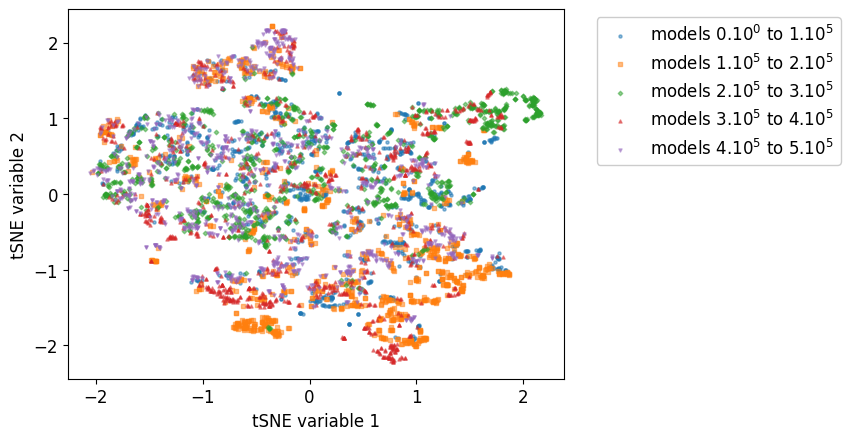

In [ ]:
print('Now loading data and metrics')

# -------- load data misfit.
# with open(rt_file_name[0] + '_metrics.pckl', "rb") as file:  # load_inv_metrics can be removed.

with open(rt_file_name[0] + '_metrics.pckl', "rb") as file:  # load_inv_metrics can be removed.
    misfit_data = pickle.load(file)
misfit_data = misfit_data[:-1]
misfit_data = misfit_data[burn_in:2*burn_in]
misfit_data = misfit_data[::save_interval]

t_sne_clust = True
haralick_clust = False
if t_sne_clust and haralick_clust:
    raise "wrong values!"
# -------- get the output from t-SNE
# Load the t-sne 2D variables.
tsne_data_orig = np.load('./results_tSNE_Haralick/tsne_data_density_models_full.npy').T

print('loaded data+metrics.')
print('')

### Use the tSNE space to assess the quality of sampling - using all models.

In the 2D tSNE space, each point represents 1 model from the chain following the same order as the chain. In `misfit_data` and `tsne_data`, the values are ordered accordingly with the position of the respective models in the chain. That is, the 1st va;ie is for the 1st model, and so on. 

#### Plot for all models.

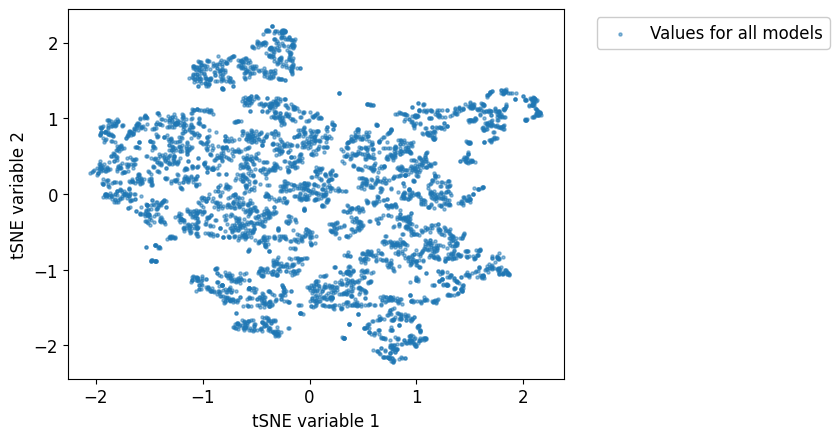

In [16]:
tsne_data_orig = StandardScaler().fit_transform(tsne_data_orig)

# Extract the t-SNE data only for the models between it 200,000 and 400,000.
tsne_data_ = tsne_data_orig.copy()

# Assess the coverage of t-sne model space for the different parts of the chain.

plt.scatter(tsne_data_orig[:, 0], 
            tsne_data_orig[:, 1], 
            s=5, alpha=0.5, label='Values for all models')

plt.xlabel('tSNE variable 1')
plt.ylabel('tSNE variable 2')
plt.legend(framealpha=1, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

#### Differentiate depending on position on the chain.

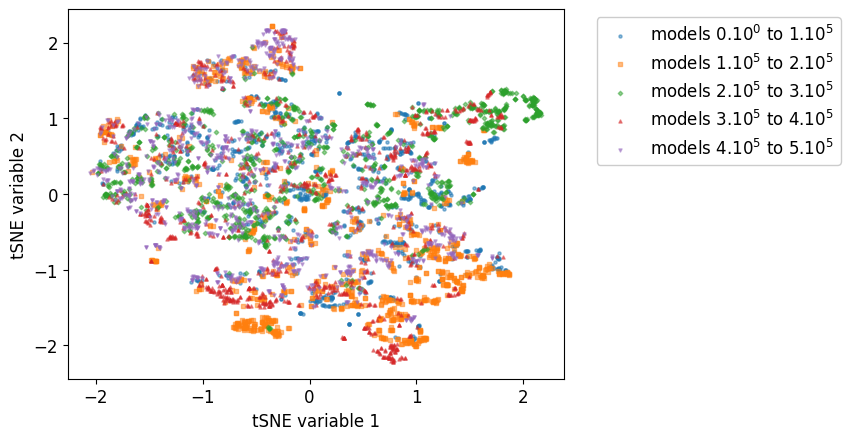

In [17]:
tsne_data_orig = StandardScaler().fit_transform(tsne_data_orig)

# Extract the t-SNE data only for the models between it 200,000 and 400,000.
tsne_data_ = tsne_data_orig.copy()

# Assess the coverage of t-sne model space for the different parts of the chain.
markers = ['o', 's', 'D', '^', 'v']  # Circle, square, diamond, triangle up, triangle down
plt.figure()
for i in range(5):
    plt.scatter(tsne_data_orig[1000 * i:1000 * (i + 1), 0], 
                tsne_data_orig[1000 * i:1000 * (i + 1), 1], 
                s=5, alpha=0.5, marker=markers[i],  # Assign a different marker
                label=r'models ${%d}$.$10^{%d}$ to ${%d}$.$10^{%d}$' % 
                    (i, np.log10(1000*i*100+1), i+1, np.log10(1000*(i+1)*100+1)))

plt.xlabel('tSNE variable 1')
plt.ylabel('tSNE variable 2')
plt.legend(framealpha=1, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()


### Keep only models with selected data misfits

`data_misfit_max` sets a threshold used to discared all models with a data misfit $\geq$ `data_misfit_max`.

In [ ]:
# Pre-processing
data_misfit_max     = np.inf  # np.inf to keep all. Otherwise: suggested value of 0.5.

# Keep only models with specific misfit.
indices_models_keep = np.where(misfit_data < data_misfit_max)
# density_models = np.squeeze(density_models[:, :, :, indices_models_keep])

# Keep only the data with misfit values inferior to threshold. TODO: remove that part?
tsne_data = tsne_data_[indices_models_keep]

X_clust = tsne_data.copy()
# tsne_data = StandardScaler().fit_transform(tsne_data)

# Number of models remaining.
n_models = np.max(np.shape(tsne_data))
print('For a max. misift of ' + str(data_misfit_max) + ', ' + str(n_models) + ' model are retained (post burnin).')
print('Size of the dataset used for clustering: ', np.shape(X_clust))

### Clustering using HDBSCAN

We use HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) to detect clusters based on the density of data points.

Here are the key parameters used:

- **`min_cluster_size = 4`**  
  This determines the **minimum number of points required to form a cluster**. Any cluster with fewer than 4 points is discarded as noise or considered part of a larger cluster. Smaller values lead to more, smaller clusters, while larger values enforce more compact, dense groupings.

- **`cluster_selection_epsilon = 0.10`**  
  This sets a **distance threshold** for separating clusters. It controls how close points can be to still be considered part of the same cluster. Lower values make the algorithm more conservative, potentially splitting up larger clusters. (Note: this parameter is specific to variations like HDBSCAN.)

- **`min_samples = 10`**  
  This defines the **number of neighbors a point needs to be considered a core point**. It influences how sensitive the algorithm is to noise. Higher values result in fewer core points and thus more conservative clustering (more points treated as noise).

> These parameters together control the granularity and robustness of the clustering results. Tuning them allows you to balance between detecting fine structures and avoiding over-fragmentation.



In [ ]:
# For eps: high eps, few cluster. low eps, more cluster.
PARAM = (
    {"min_cluster_size": 4, "cluster_selection_epsilon": 0.10, "min_samples": 10, "store_centers": "centroid", "metric": 'manhattan'},
    {"min_cluster_size": 4, "cluster_selection_epsilon": 0.10, "store_centers": "centroid", "metric": 'manhattan'},
        )

fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12), dpi=600)
for i, param in enumerate(PARAM):
    db_clust = HDBSCAN(**param).fit(X_clust)
    labels = db_clust.labels_
    print_info_clusters(labels)

    db_clust.core_sample_indices_ = get_core_indices(tsne_data, labels)
    labels = db_clust.labels_

    plot_clust_colors(tsne_data, labels, db_clust.probabilities_, param, ax=axes[i])
    
plt.show()

Size of the dataset used for clustering:  (2500, 2)
Estimated number of clusters: 62
Estimated number of noise points: 522 on 2500 models)
Estimated number of clusters: 90
Estimated number of noise points: 102 on 2500 models)


### Plotting the results of the last results of clustering.

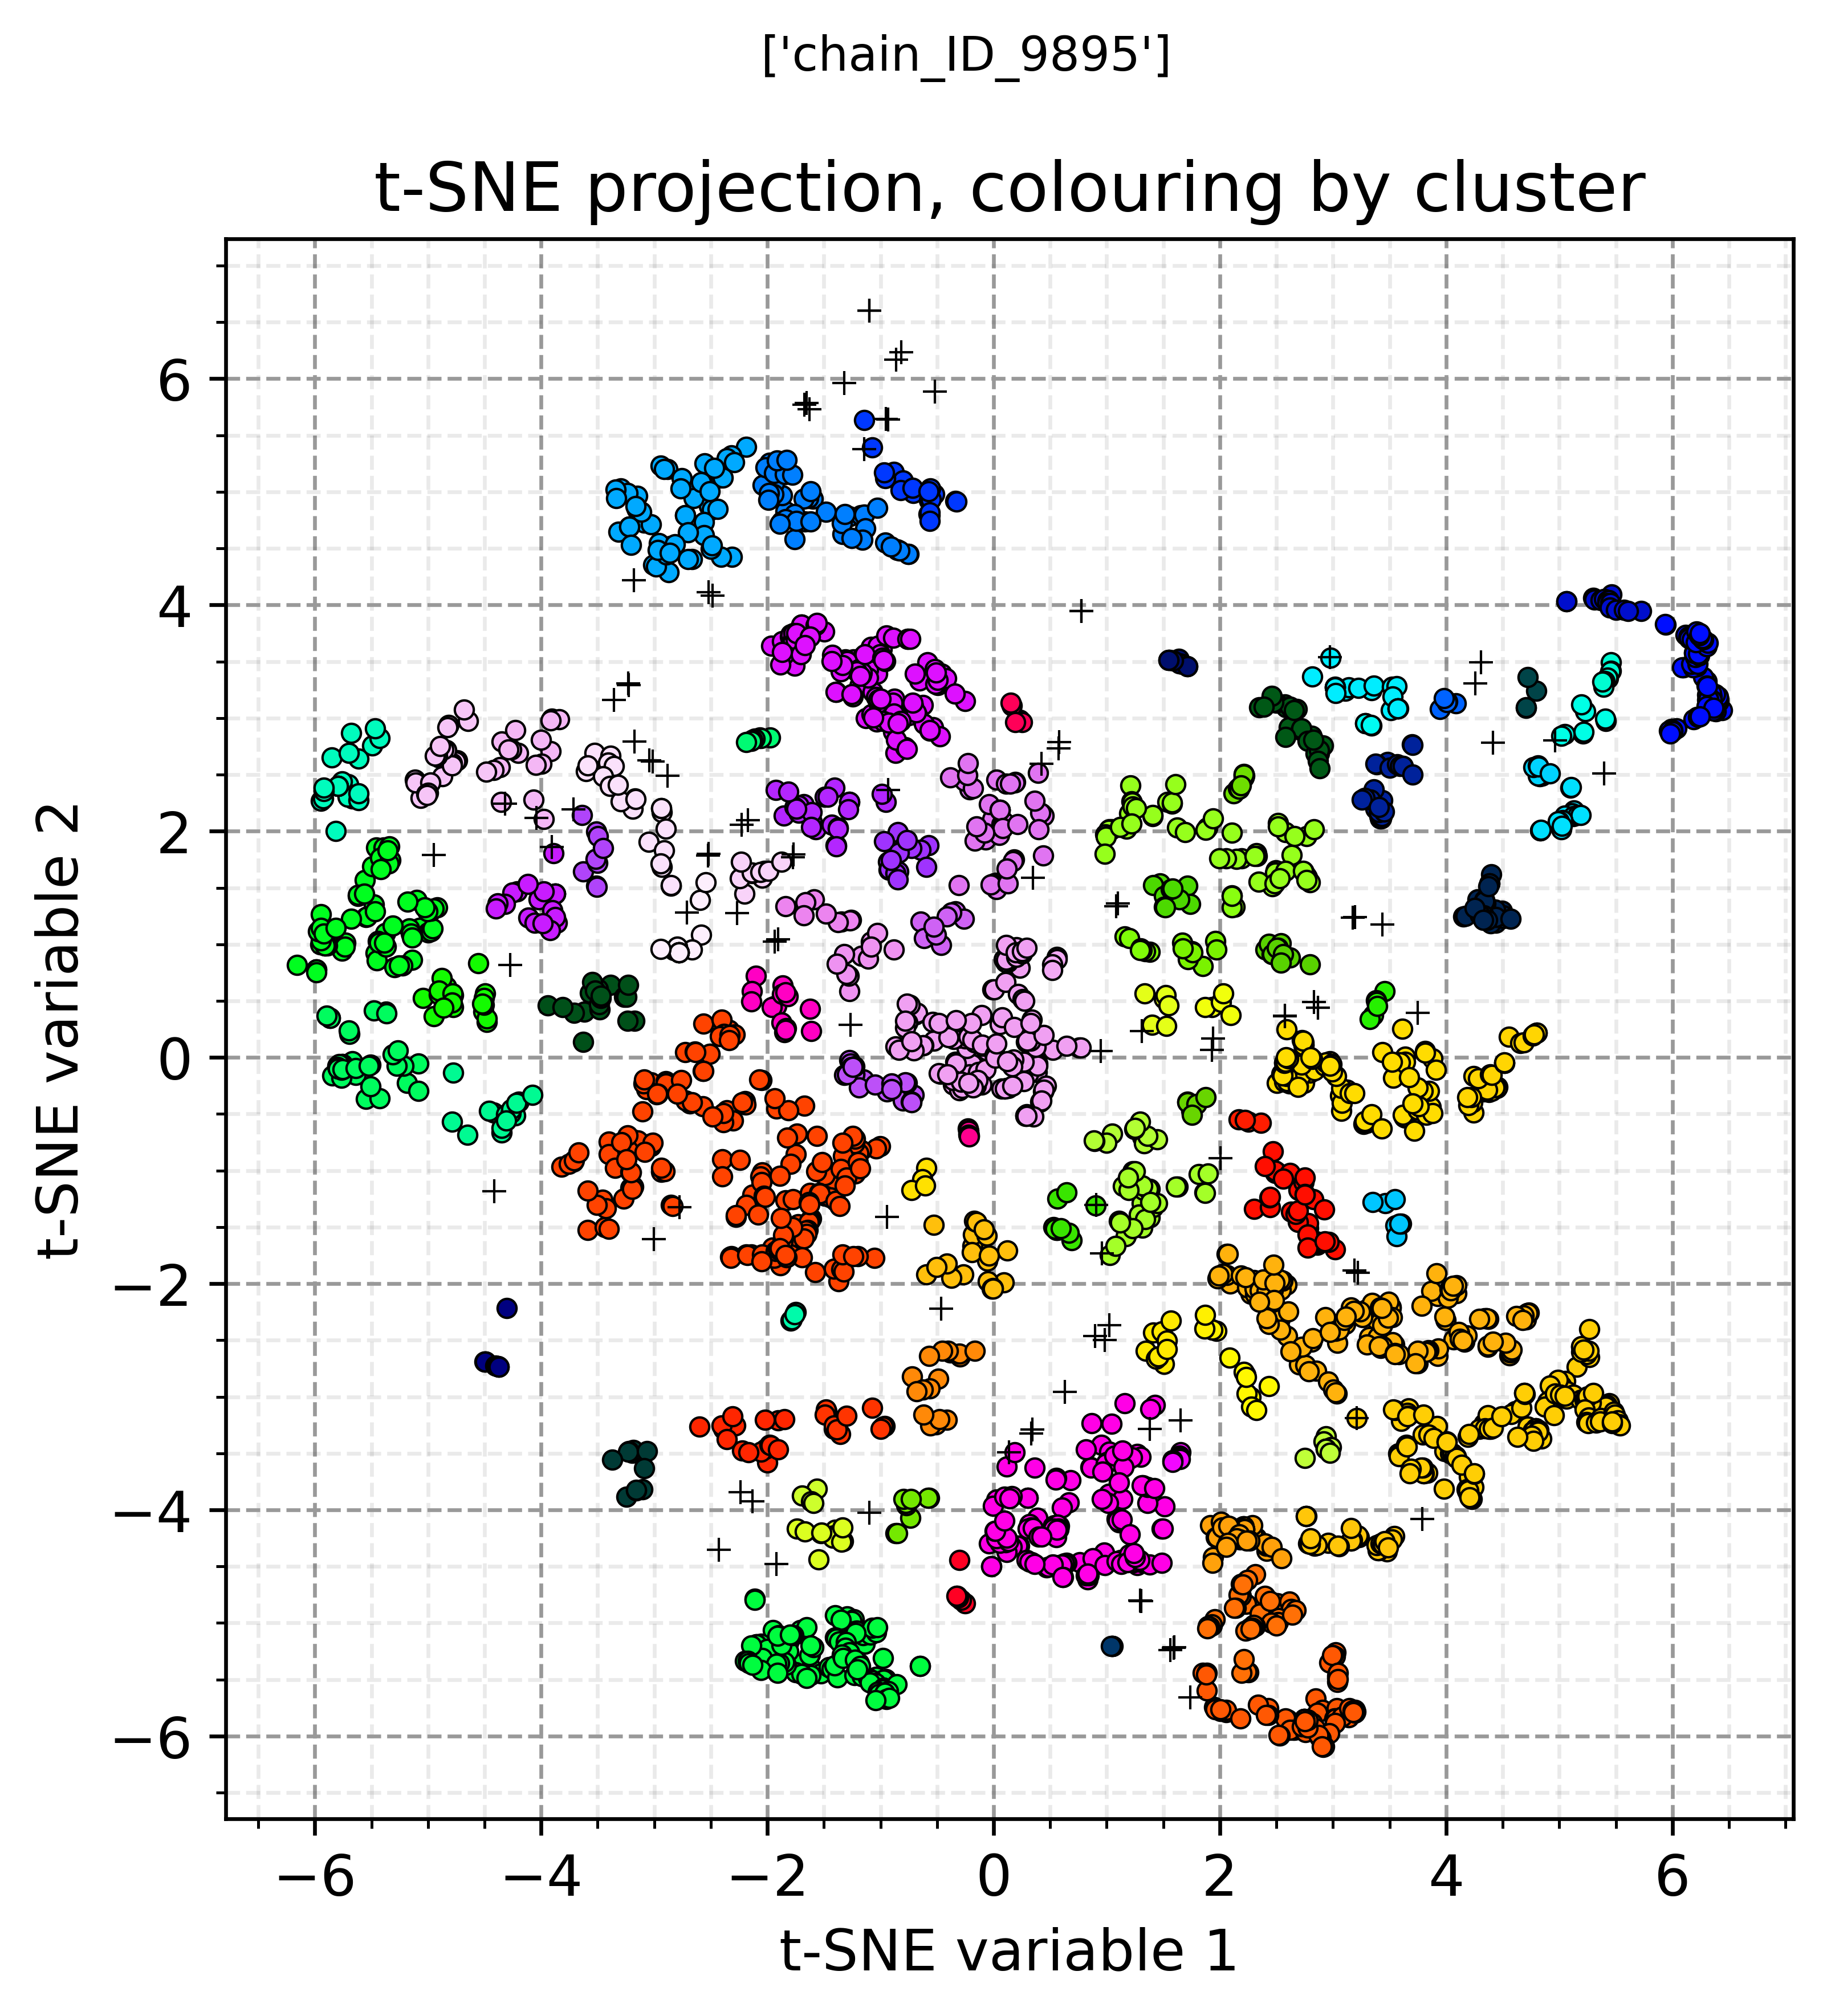

In [5]:
# Just for plots.
tsne_data_resize = (tsne_data.copy() - np.mean(tsne_data)) * 3

fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)

#- Plot the models for specific clusters.
# Get the number of models for the cluster.
ind_clust = 5  # Cluster to plot.

class_member_mask = (labels == ind_clust)
# Extract the core samples.
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db_clust.core_sample_indices_] = True
model_indices = np.array(list(range(n_models)))
indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
n_models_cluster = len(indices_models_tmp)

In [ ]:
# Set plot parameters.
canvas_width = 1./4
base_inset_size = 2.

# Get the models corresponding to the clusters using majority vote.
model_indices = np.array(list(range(n_models)))

n_models_per_clust = np.zeros_like(np.unique(labels) - 1)  # -1 because there is -1 for models classified as noise.
for k in range(len(n_models_per_clust)):
    n_models_per_clust[k] = np.shape(np.where(labels == k))[1]

ind_n_models = np.argsort(n_models_per_clust)[::-1]
ind_labels = np.arange(len(n_models_per_clust))[ind_n_models]

n_padd_x = 7

# Define the number of plots
plots = []
ind_slicey = 15  # Synth.

num_plots = len(n_models_per_clust)
print(np.shape(density_models))
density_models_ = density_models[:, :, n_padd_x:-n_padd_x, :]
density_model_true = true_model[:, :, n_padd_x:-n_padd_x]
model_mean_matrix = np.zeros((density_models_.shape[0], density_models_.shape[2], int(num_plots)))
model_std_matrix = np.zeros((density_models_.shape[0], density_models_.shape[2], int(num_plots)))

# Get the number of models for the cluster.
class_member_mask = (labels == ind_labels[0])
# Extract the core samples.
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db_clust.core_sample_indices_] = True
indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
n_models_cluster = len(indices_models_tmp)

# Generate plots closer to the layout on t-SNE representation.
placed_plots = []
for i in range(0, num_plots - 1):
    # Get the number of models for the cluster.
    class_member_mask = (labels == ind_labels[i])
    # Extract the core samples.
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db_clust.core_sample_indices_] = True
    indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
    n_models_cluster = len(indices_models_tmp)

    models_tmp = density_models_[:, :, :, indices_models_tmp]

    models_mean_tmp = np.mean(models_tmp, axis=3)
    models_mean_tmp = np.squeeze(models_mean_tmp[:, :, :])
    model_mean_matrix[:, :, i] = models_mean_tmp

    models_std_tmp = np.std(models_tmp, axis=3)
    models_std_tmp = np.squeeze(models_std_tmp[:, :, :])
    model_std_matrix[:, :, i] = models_std_tmp

    xy = tsne_data_resize[class_member_mask & core_samples_mask]

    size_factor = base_inset_size * np.sqrt(n_models_cluster / np.max(n_models_per_clust))
    width = size_factor * (66 - 2 * n_padd_x) / 30
    height = size_factor

    x0 = np.mean(xy[:, 0]) - width / 2
    y0 = np.mean(xy[:, 1]) - height / 2
    _, placed_plots = update_placed_plots(placed_plots, i, x0, y0, width, height, x0, y0, width, height)

# Run the overlap resolution
placed_plots_orig = placed_plots.copy()
resolve_overlaps_1(placed_plots, canvas_width=canvas_width)


(30, 1, 66, 2500)


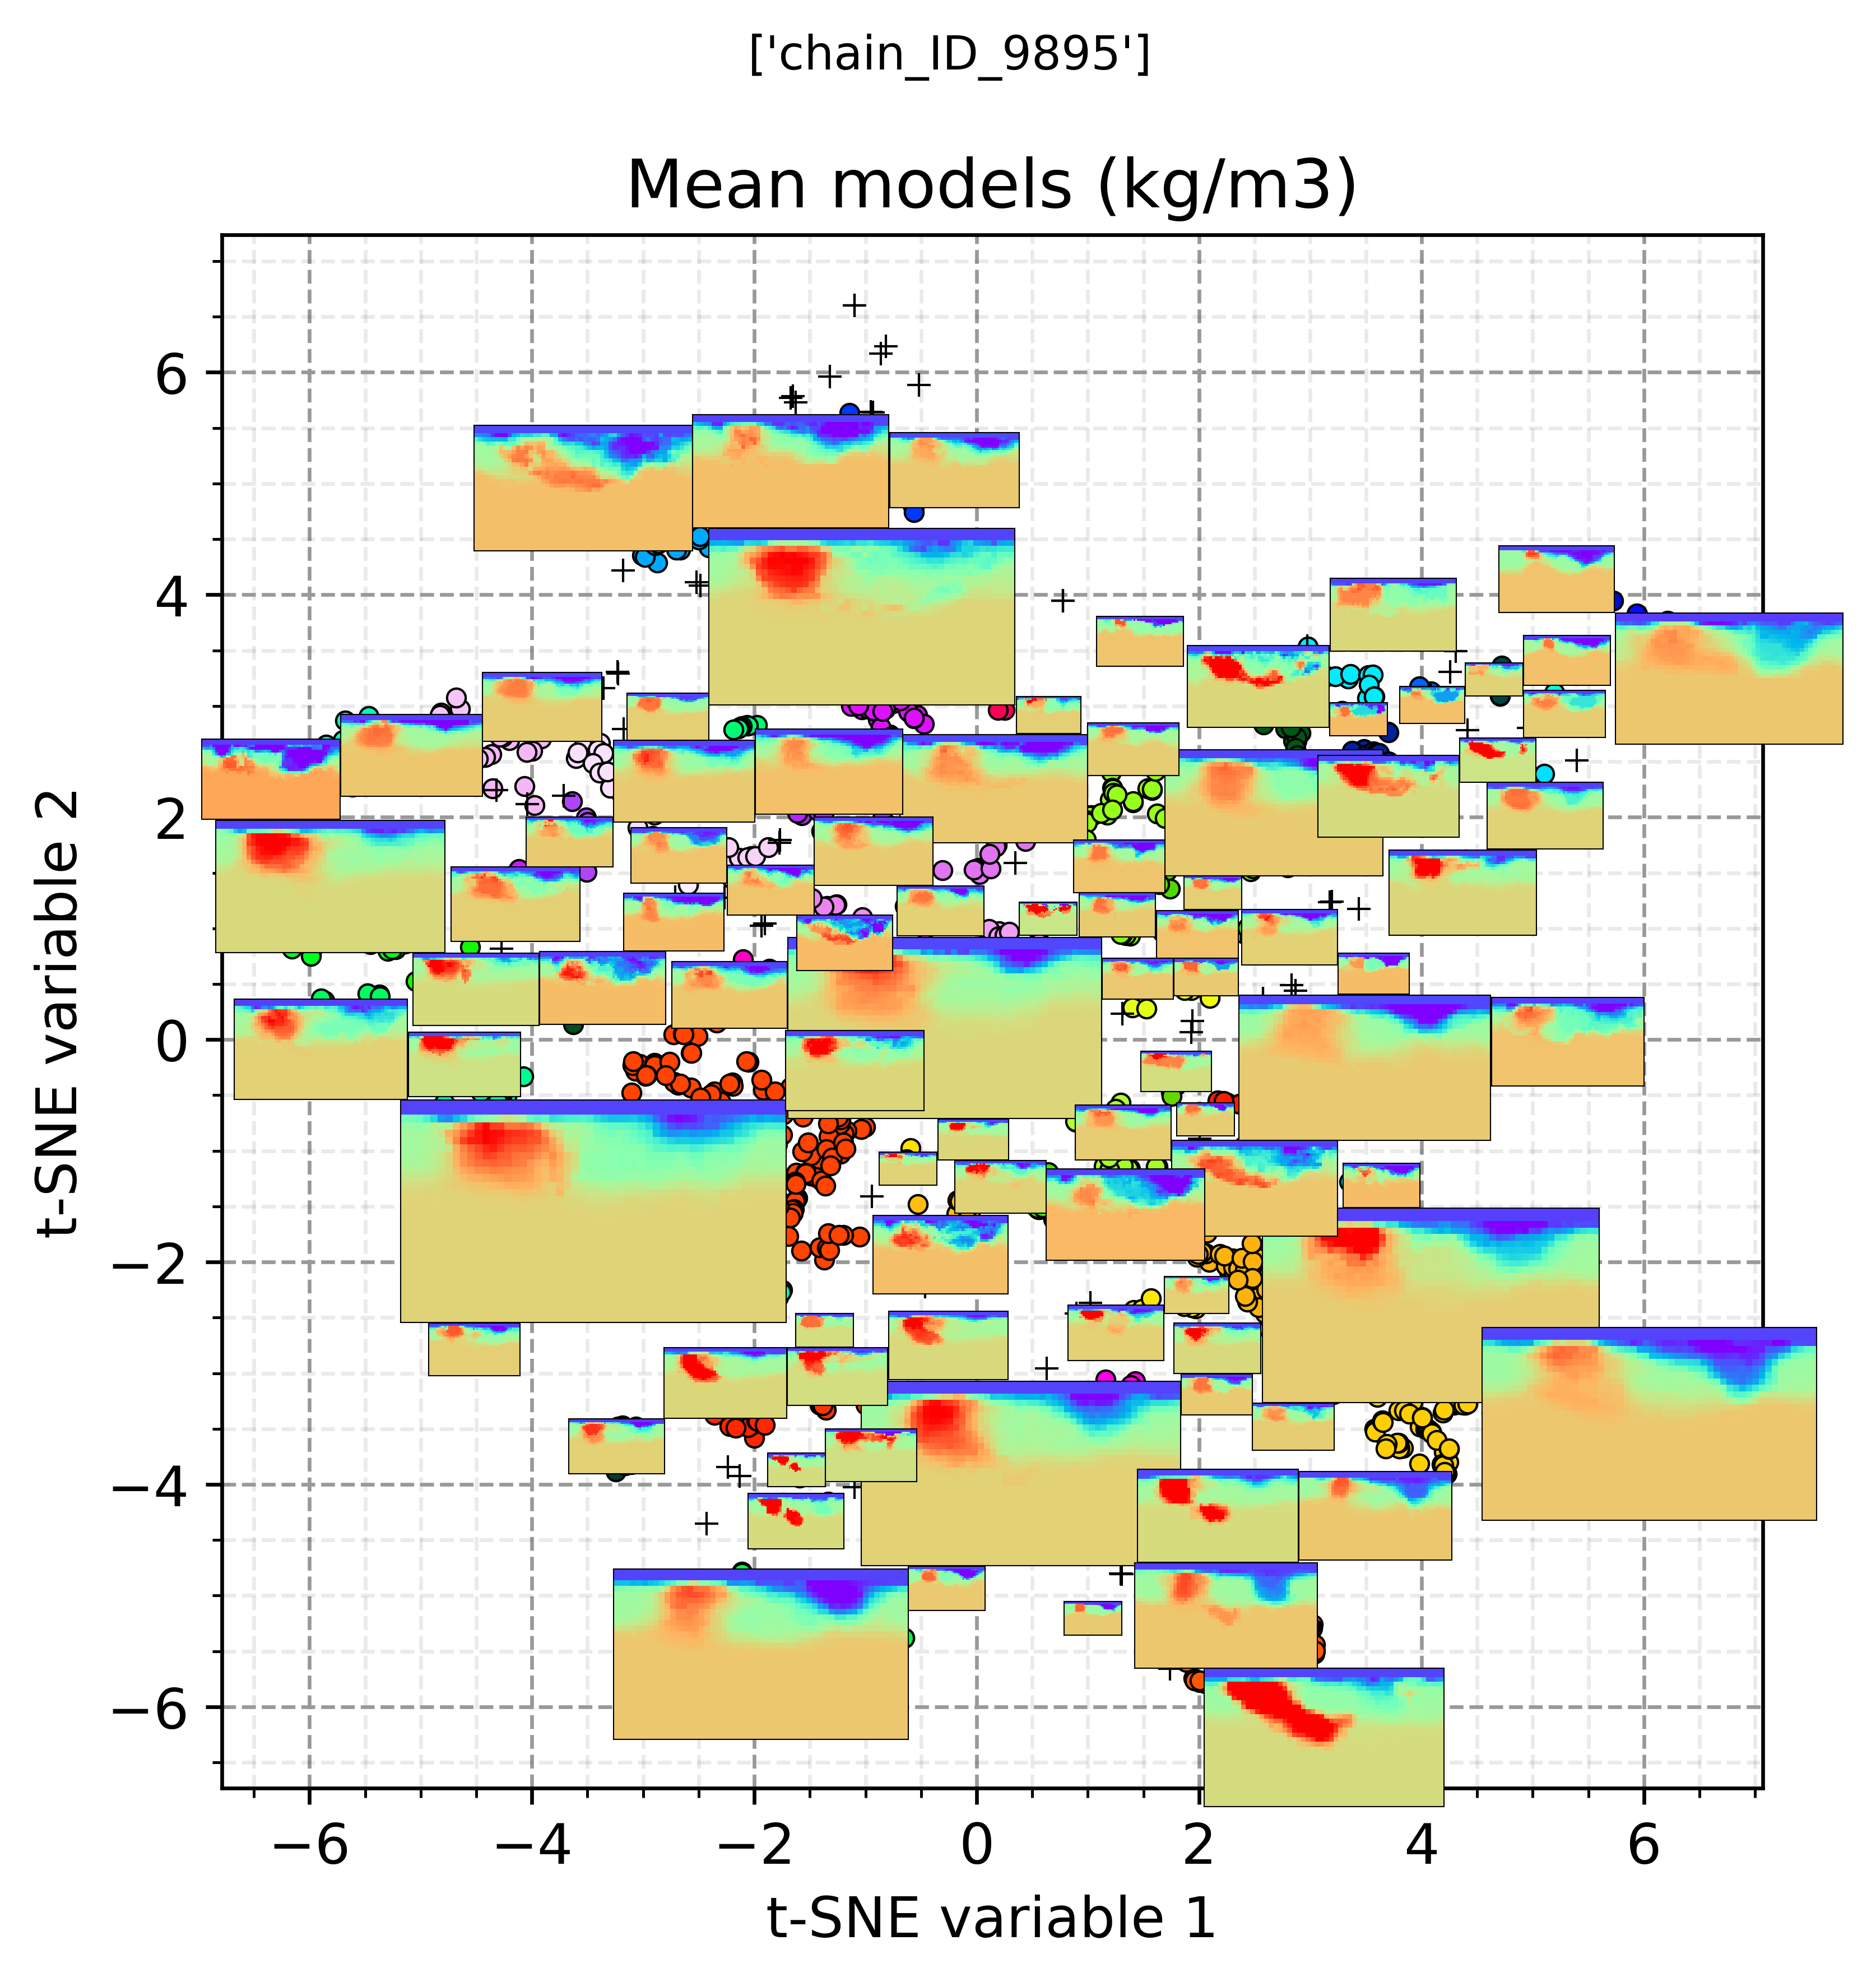

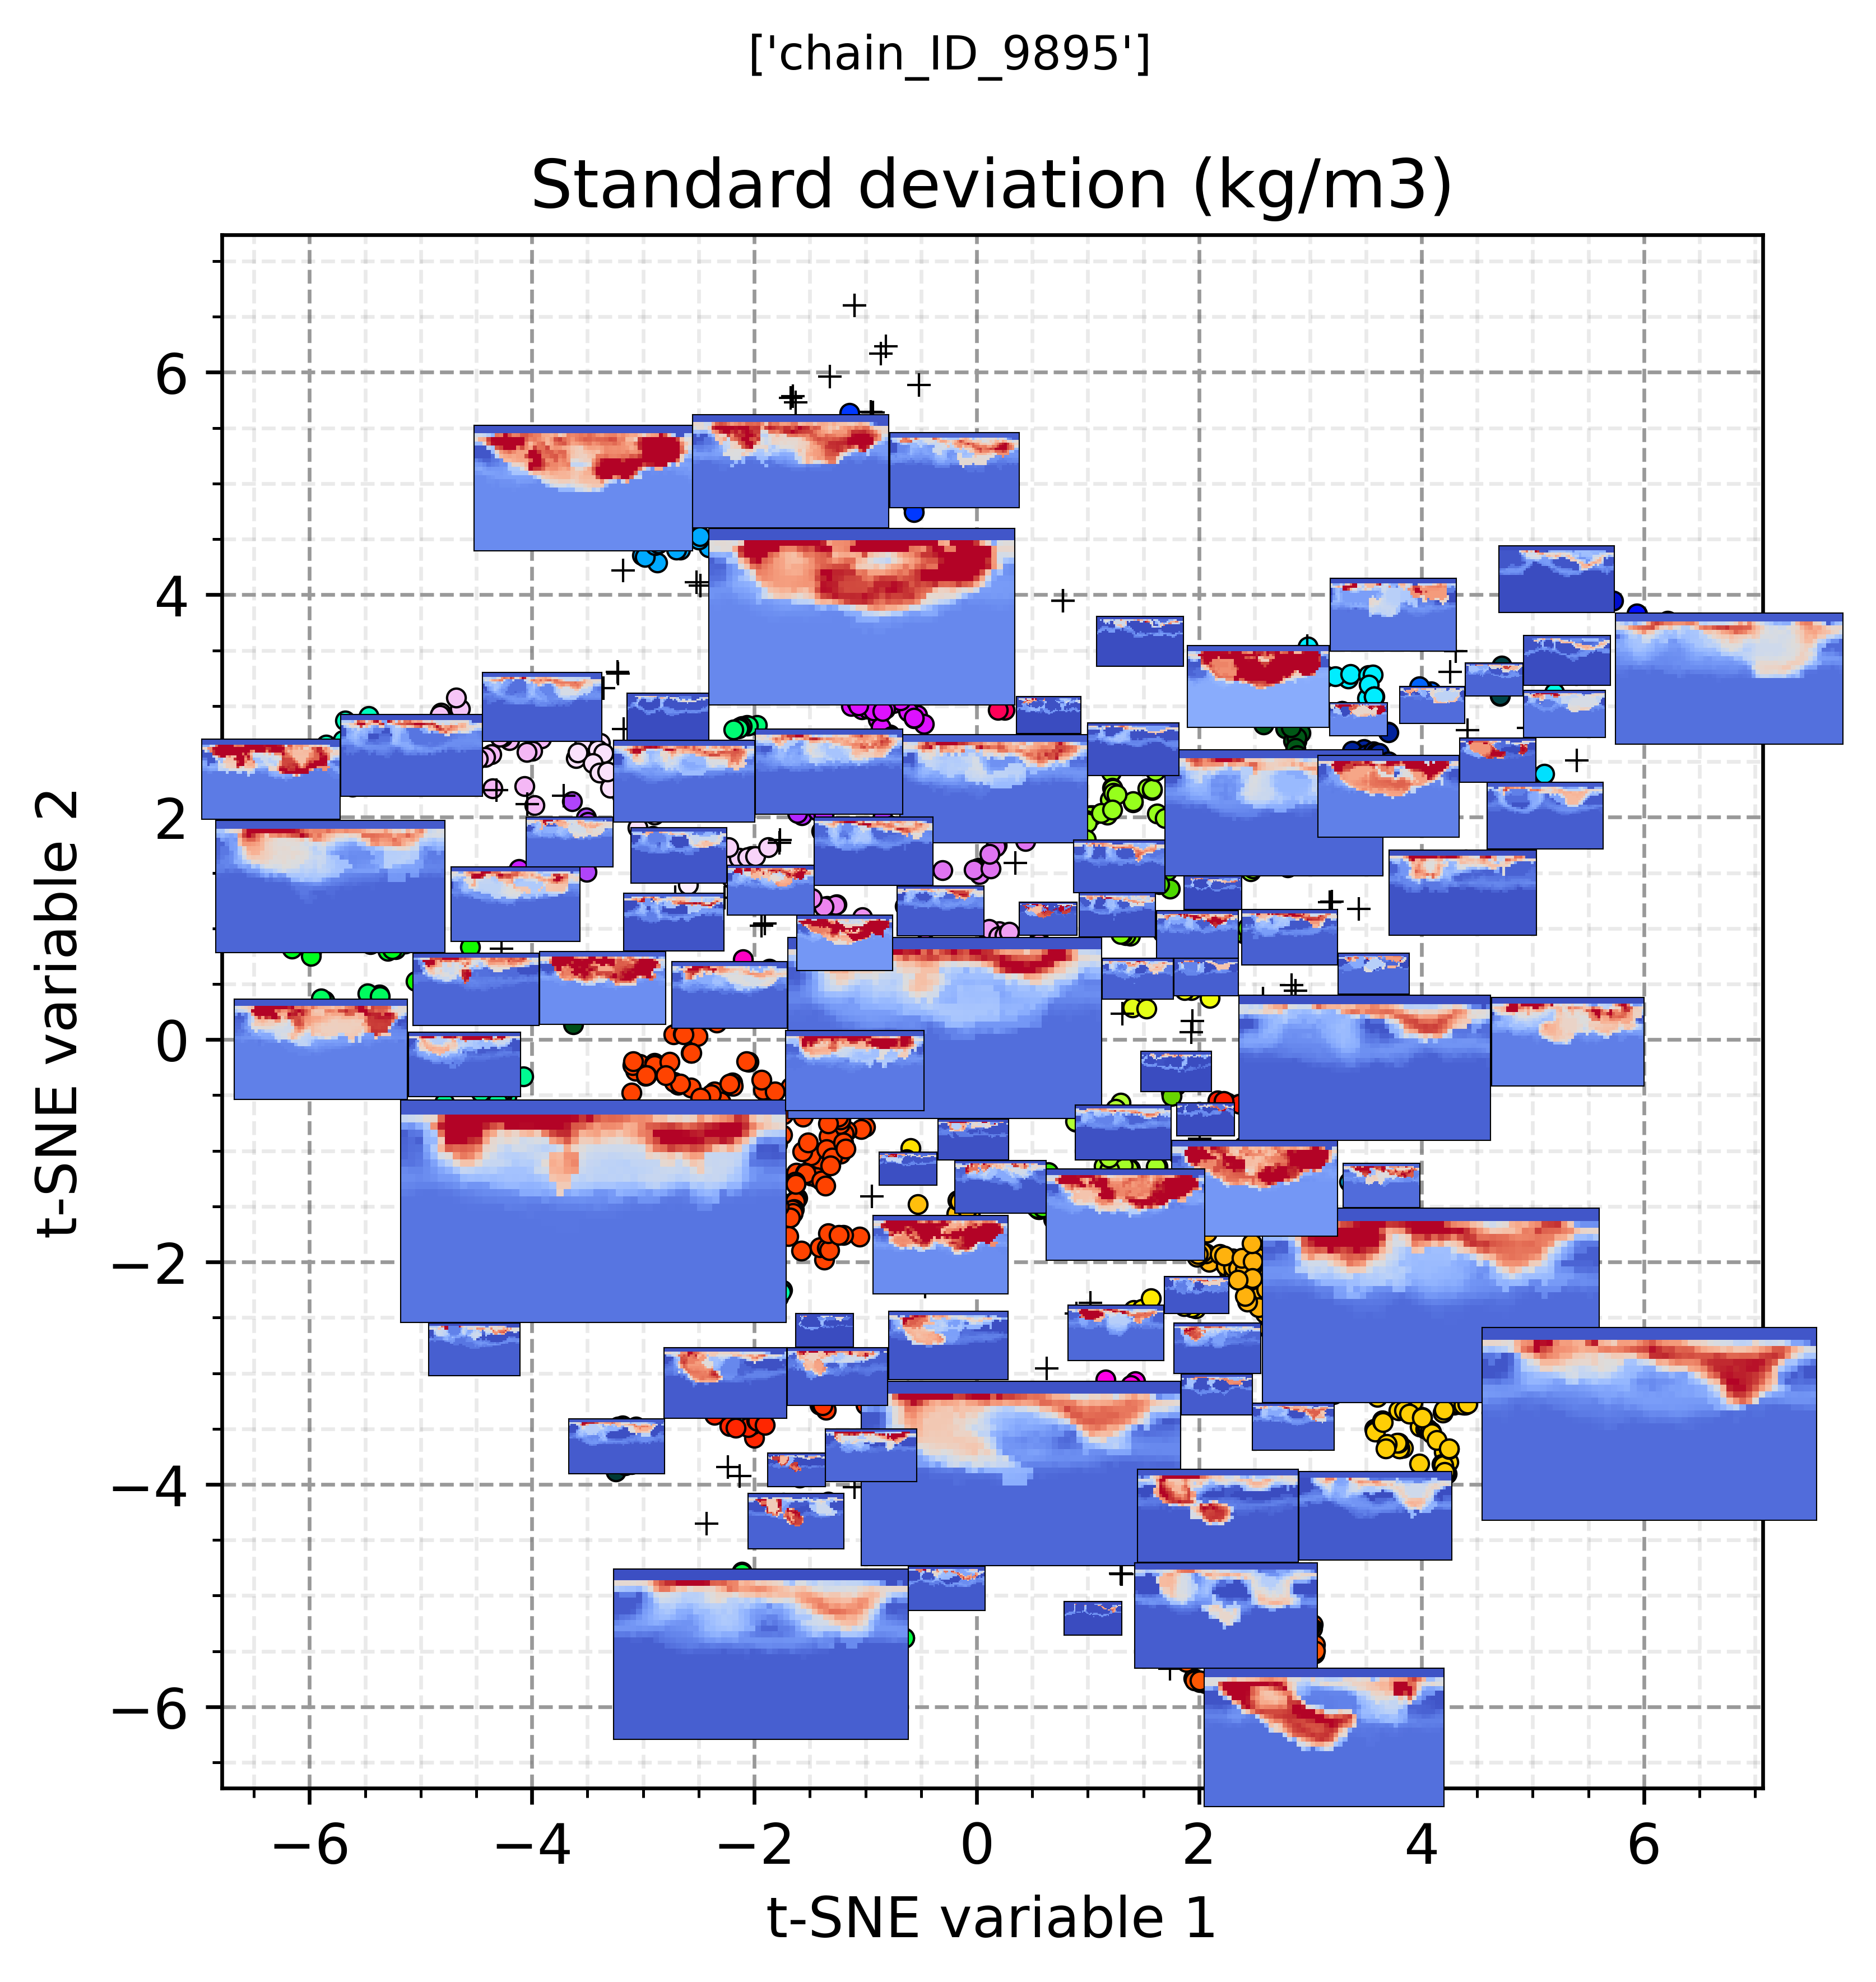

In [ ]:
# Plots for the mean models. 
fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)

i = 0
for plot in placed_plots:
    inset_axes = create_inset(ax=ax, x=plot["x"], y=plot["y"], width=plot["width"], height=plot["height"])
    im0 = inset_axes[-1].imshow(model_mean_matrix[:, :, i], zorder=0, cmap='rainbow', interpolation='None')
    im0.set_clim((-130, 100))
    i += 1

ax.set_title('Mean models (kg/m3)')
plt.show()


# Plots for the std models. 
fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)
i = 0
for plot in placed_plots:
    inset_axes = create_inset(ax=ax, x=plot["x"], y=plot["y"], width=plot["width"], height=plot["height"])
    im0 = inset_axes[-1].imshow(model_std_matrix[:, :, i], zorder=0, cmap='coolwarm', interpolation='None')
    im0.set_clim((0, 100))
    i += 1

ax.set_title('Standard deviation (kg/m3)')
plt.show()

